<a href="https://colab.research.google.com/github/kkuope/CERN/blob/main/materiaali/harjoitukset/01_LaskeInvarianttiMassa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Laske invariantti massa

Tässä tehtävässä opetellaan laskemaan CMS-ilmaisimessa havaittujen hiukkasten __invariantti massa__. Invariantti massa on hiukkasfyysikoille tärkeä työkalu hiukkasten tunnistamisessa.

## Mikä on invariantti massa?
Hiukkasilla on nille ominainen massa, joka kuvaa hiukkasen hitautta. Se on sama massa $m$ jota käytetään Newtonin toisessa laissa $F=ma$ ja Einsteinin yhtälössä $E=mc^2$ (missä E viittaa hiukkasen energiaan levossa). On mahdoton ajatus punnita esimerkiksi Higgsin hiukkasta jonka eliniänodote on luokkaa $10^{-22}$ sekuntia [2]. Kun hiukkanen, vaikkapa Higgsin hiukkanen hajoaa, syntyy jälleen uusia hiukkasia. Hiukkasen hajoamisesta sinkoilevat uudet hiukkaset taas saattavat kulkea jopa valonnopeudella eikä niillä välttämättä edes ole massaa (esim. fotonit). CMS:n kaltainen laite voi kuitenkin mitata näiden hiukkasten liikemäärää ja energiaa, joiden avulla voidaan laskea _invariantti massa_. Se on matemaattinen arvo joka on "invariantti" mittausympäristölle, eli se voidaan laskea missä ja mille tahansa. Jos sen kuitenkin laskee tietystä hajoamisesta syntyneille tytärhiukkasille saadaan arvo joka on lähellä emohiukkasen massaa. Esimerkiksi Higgsin hiukkanen voi hajota neljäksi elektroniksi, joiden liikemäärän ja energian voimme mitata hiukkasilmaisimella. Näiden neljän elektronin liikemäärästä ja energiasta voimme laskea invariantin massan, joka vastaisi Higgsin hiukkasen massaa, sillä elektronit ovat peräisin Higgsistä.

Invariantti massa siis säilyy hiukkasen hajotessa uusiksi hiukkasiksi. Tämän ominaisuuden ansiosta se on voittamaton työkalu kokeellisen hiukkasfysiikan tutkijoille. Hiukkasilmaisin, kuten CMS, havaitsee lähinnä stabiileja hiukkasia. Määrittääkseen sen, minkä hiukkasen hajoamisesta nuo stabiilit hiukkaset ovat peräisin, tutkijoiden tulee tarkastella suuria datamääriä. Voimme laskea invariantin massan usealle eri hajoamistapahtumalle ja piirtää kaikista laskemistamme invarianteista massoista histogrammi.
[Lisätietoa englanniksi](https://profmattstrassler.com/articles-and-posts/particle-physics-basics/mass-energy-matter-etc/mass-and-energy/)

Alla olevassa kuvassa on piirretty invariantin massan histogrammi sellaisista törmäyksistä, joissa hiukkasilmaisin on havainnut kaksi myonia. Piikit histogrammissa vastaavat emohiukkasta, josta myonit ovat peräisin.

![](https://github.com/cms-opendata-education/cms-jupyter-materials-finnish/blob/master/Kuvat/inv_massa.PNG?raw=true)

****
### Datan hakeminen

Tarkoituksenamme on piirtää invariantin massan histogrammi CMS:n avoimesta datasta vuodelta 2010. Dataan on valikoitu tapahtumia joissa syntyy kaksi suurienergistä myonia. Data on tallennettu csv-muotoon tiedostoon 'Zmumu.csv' [1]. Kyseisessä tiedostossa on laskettu jo valmiiksi invariantti massa, mutta lasketaan se muiden muuttujien avulla harjoituksen vuoksi. Alustetaan lasku hakemalla käyttämämme data sekä tarvittavat moduulit (eli koodikirjastot, jotka mahdollistavat valmiiksi määriteltyjen funktioiden käytön).

Muista. että voit ajaa koodisolun klikkaamalla sen aktiiviseksi ja painamalla CTRL+ENTER.

In [1]:
# Haetaan tarvittavat moduulit. Nimetään pandas-moduuli 'pd'ksi ja numpy-moduuli 'np'ksi, jotta koko nimeä ei
# tarvitse kirjoittaa aina, kun haluamme käyttää jotain funktiota kyseisestä moduulista.
import pandas as pd
import numpy as np

# Haetaan data ja tallennetaan se muuttujaan 'datasetti'. Data voidaan hakea tiedostosta pandas-moduulin
# read_csv() -funktiolla. Sulkeiden sisään kirjoitetaan datatiedoston polku.
datasetti = pd.read_csv('http://opendata.cern.ch/record/307/files/Zmumu.csv')

Saamme tarkistettua tallentamamme datan sisällön tulostamalla tiedoston viisi ensimmäistä riviä alla olevalla koodilla:

In [2]:
# head() -metodi näyttää datan viisi ensimmäistä riviä.

datasetti.head()

,Type,Run,Event,E1,px1,py1,pz1,pt1,eta1,phi1,Q1,E2,px2,py2,pz2,pt2,eta2,phi2,Q2,M
0,GT,148031,10507008,82.201866,-41.195288,17.433244,-68.964962,44.7322,-1.217690,2.741260,1,60.621875,34.144437,-16.119525,-47.426984,38.8311,-1.05139,-0.440873,-1,82.462692
1,TT,148031,10507008,62.344929,35.118050,-16.570362,-48.775247,38.8311,-1.051390,-0.440873,-1,82.201866,-41.195288,17.433244,-68.964962,44.7322,-1.21769,2.741260,1,83.626204
2,GT,148031,10507008,62.344929,35.118050,-16.570362,-48.775247,38.8311,-1.051390,-0.440873,-1,81.582778,-40.883323,17.299297,-68.447255,44.7322,-1.21769,2.741260,1,83.308465
3,GG,148031,10507008,60.621875,34.144437,-16.119525,-47.426984,38.8311,-1.051390,-0.440873,-1,81.582778,-40.883323,17.299297,-68.447255,44.7322,-1.21769,2.741260,1,82.149373
4,GT,148031,105238546,41.826389,22.783582,15.036444,-31.689894,27.2981,-0.990688,0.583351,1,49.760726,-20.177373,-9.354149,44.513955,21.8913,1.44434,-2.707650,-1,90.469123


Haetussa datassa on monta tapahtumaa (event), joista jokaisesta on tallennettu useita arvoja. Tehtävän kannalta oleellisimpia ovat,
   - __Run__ ja __Event__ : kertovat mistä törmäyksestä kyseisen rivin data on peräisin.
   - __E__ : kyseisen myonin (1 tai 2) energia.
   - __px,py,pz__: myonin liikemäärän komponentit.

****
### Invariantin massan laskeminen

Käytetään laskussa seuraavaa lauseketta invariantille massalle $M$:


$$ M = \sqrt{(E_1 + E_2)^2 - \|\textbf{p}_1 + \textbf{p}_2 \| ^2} = \sqrt{(E_1+E_2)^2-((p_{1_x}+p_{2_x})^2+(p_{1_y}+p_{2_y})^2+(p_{1_z}+p_{2_z})^2)},$$

missä $\textbf{p}$ sisältää liikemäärän kaikki komponentit. Yllä oleva lauseke antaa meille tarkan arvon invariantille massalle, ja käytetään sitä aina kun mahdollista.

Joistakin dataseteistä ei kuitenkaan löydy liikemäärän komponentteja suoraan. Tällöin voidaan käyttää approksimaatiota, joka sopii tilanteisiin, joissa E >> m (kuten kiihdyttimissä tuppaa olemaan). Tässä lausekkeessa $p_T$ on liikemäärän hiukkassuihkua vastaan kohtisuora komponentti, $\eta$ pseudorapiditeetti ja $\phi$ atsimuuttikulma:

$$M = \sqrt{2p_{T1}p_{T2}(\cosh(\eta_1-\eta_2)-\cos(\phi_1-\phi_2))}.$$


Alla olevassa laskussa käytämme apuna *numpy*-moduulia, jonka nimesimme yllä *np*:ksi. Moduulin avulla voimme suorittaa matemaattisia komentoja, esimerkiksi *sqrt* ja *cosh* kutsumalla ensin moduulin nimeä ja pisteellä erottaen komentoa (esimerkiksi *np.sqrt*). Voimme myös helposti käyttää potensseja ilman *numpy*-kirjastoa käyttämällä \*\*-operaattoria (esim. x² kirjoitetaan x**2).

Nyt voimme laskea invariatin massan arvot eri tapahtumille. Datassa esiintyviin muuttujiin pääset käsiksi kirjoittamalla '*datasetti.muuttuja*'. Esimerkiksi, jos haluat valita datasetistä kaikki myonin 1 energian arvot, voit kirjoittaa koodisoluun '*datasetti.E1*'.

> Laske kaikille tapahtumille invariantti massa ja tallenna ne muuttujaan 'invariantti_massa'
<br>
$\color{purple}{\text{Kirjoita koodi alle}}$

In [3]:
# Laske invariantti massa ja tallenna muuttujana invariantti_massa
invariantti_massa = np.sqrt(2 * datasetti.pt1 * datasetti.pt2 * (np.cosh(datasetti.eta1 - datasetti.eta2) - np.cos(datasetti.phi1 - datasetti.phi2)))



> Tarkasta aiemmin käytetyn head() -metodin avulla, mitä muuttuja *invariantti_massa* nyt sisältää.
<br>
$\color{purple}{\text{Kirjoita koodi alle}}$

In [4]:
# Tulosta näytölle muuttujan invariantti_massa viisi ensimmäistä riviä
invariantti_massa.head(5)


,0
0,83.625932
1,83.625932
2,83.625932
3,83.625932
4,89.757413


Aja alla oleva koodi nähdäksesi invariantin massan histogrammi laskemistasi arvoista. Histogrammin piirtämiseen palataan tarkemmin harjoituksessa 2.

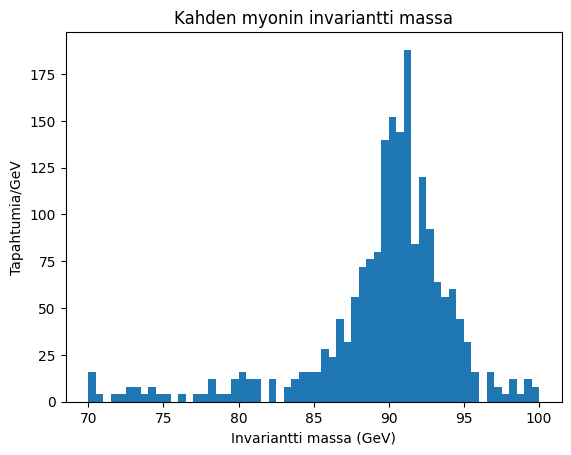

In [15]:
import matplotlib.pyplot as plt

plt.hist(invariantti_massa, bins=60, range=(70, 100))
plt.title('Kahden myonin invariantti massa')
plt.xlabel('Invariantti massa (GeV)')
plt.ylabel('Tapahtumia/GeV')
plt.show()

> Mitä invariantin massan histogrammi kertoo?
<br>
> Miksi noin 90 GeV kohdalla on enemmän tapahtumia kuin muualla?

### Lähteet

[1]  McCauley, Thomas; (2014). Z to two muons from 2010. CERN Open Data Portal. [DOI:10.7483/OPENDATA.CMS.XBN9.HFGT](http://doi.org/10.7483/OPENDATA.CMS.XBN9.HFGT)

[2] Determination of the off-shell Higgs boson signal strength in the high-mass ZZ final state with the ATLAS detector.
Url: https://atlas.cern/updates/physics-briefing/higgs-boson-s-shadow

### Kuvat
[Kuva 1] HLT Dimuon Invariant Mass Distributions in 2017 and 2018 ( CMS DP-2018/055)
Url: https://twiki.cern.ch/twiki/bin/view/CMSPublic/HLTDiMuon2017and2018